# S2 Coursework DRAFT

## Question 1: Accident data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
mining_data = np.loadtxt(os.path.join('data','coal_mining_accident_data.dat'))
flattened_data = np.ndarray.flatten(mining_data, order="C")
flattened_data_cumulative = np.cumsum(flattened_data)

total_period = 40550
total_events = 191

number_of_accidents = np.arange(0, len(flattened_data_cumulative), 1)

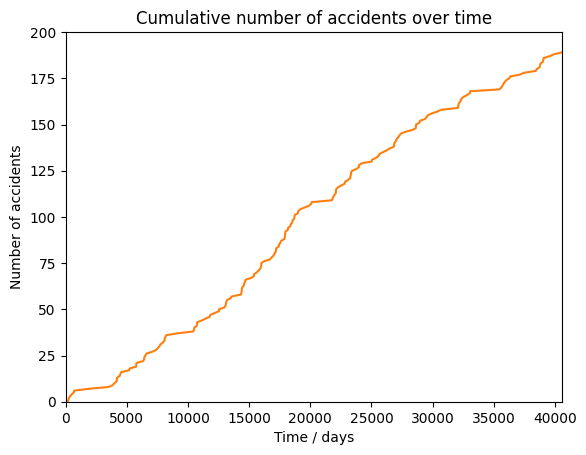

In [3]:
plt.plot(flattened_data_cumulative, number_of_accidents, color="tab:orange")
plt.xlabel("Time / days")
plt.ylabel("Number of accidents")
plt.title("Cumulative number of accidents over time")
plt.xlim(0,40550)
plt.ylim(0,200)
plt.show()

In [4]:
mean_rate = total_events / (total_period)
print(f"Mean rate of accidents: {mean_rate:.4f} per day")
mean_rate_year = number_of_accidents[-1] / (total_period / 365) # Convert total period from years to days
print(f"Mean rate of accidents: {mean_rate_year:.2f} per year")

Mean rate of accidents: 0.0047 per day
Mean rate of accidents: 1.70 per year


## Question 2: Priors

### (a)

(4,)
[ 6921.05838726  8979.27233366 28465.19025092 33135.42662946]
(4,)
[ 7163.17613807 20762.85657906 25064.39812307 39292.71894824]


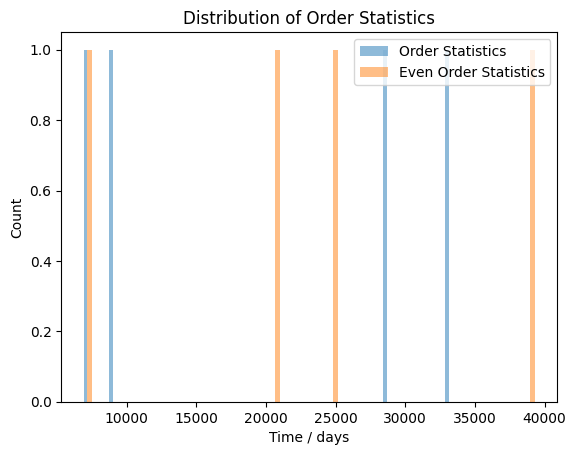

In [17]:
from scipy.stats import expon

k = 4
order_statistics = np.sort(np.random.uniform(0, total_period, k))
print(np.shape(order_statistics))
print(order_statistics)
even_order_statistics = np.sort(np.random.uniform(0, total_period, 2 * k + 1))[1:-1:2]
print(np.shape(even_order_statistics))
print(even_order_statistics)

plt.hist(order_statistics, bins=100, density=False, alpha=0.5, label='Order Statistics')
plt.hist(even_order_statistics, bins=100, density=False, alpha=0.5, label='Even Order Statistics')
plt.xlabel("Time / days")
plt.ylabel("Count")
plt.title("Distribution of Order Statistics")
plt.legend()
plt.show()

## Question 3: The constant rate model

### (a)

The prior on $h_0$ is 

\begin{equation}
    \pi(h_0|M_0)=\beta^\alpha\exp(-\beta h)/\Gamma(\alpha),
\end{equation}

where $\alpha=1$, $\beta=200\;\text{days}$. In the constant rate case, the log-likelihood is simply

\begin{equation}
    \log\mathcal{L}(\{I_i\}|h_0,M_0)=N\log h_0-h_0L.
\end{equation}

The posterior on $h_0$ is thus

\begin{equation}
    P(h_0|\{I_i\}, M_0)=200h_0^N\exp(-h_0(200+L)).
\end{equation}

In [ ]:
from scipy import special

alpha = 1
beta = 200

def constant_rate_prior(h, alpha, beta):
    return beta ** alpha * np.exp(-beta * h) / special.gamma(alpha)

def log_constant_rate_prior(h, alpha, beta):
    return alpha * np.log(beta) - beta * h - special.gammaln(alpha)

def constant_rate_likelihood(h):
    return h ** total_events * np.exp(-h * total_period)

def log_constant_rate_likelihood(h):
    return total_events * np.log(h) - h * total_period

def constant_rate_posterior(h, alpha, beta):
    return expon(h, a=alpha, scale=1/beta) * constant_rate_likelihood(h) * model_prior(0)

def log_constant_rate_posterior(h, alpha, beta):
    return np.log(expon(h, a=alpha, scale=1/beta)) + log_constant_rate_likelihood(h)

/tmp/ipykernel_39113/769097394.py:14: RuntimeWarning: divide by zero encountered in log
  return total_events * np.log(h) - h * total_period


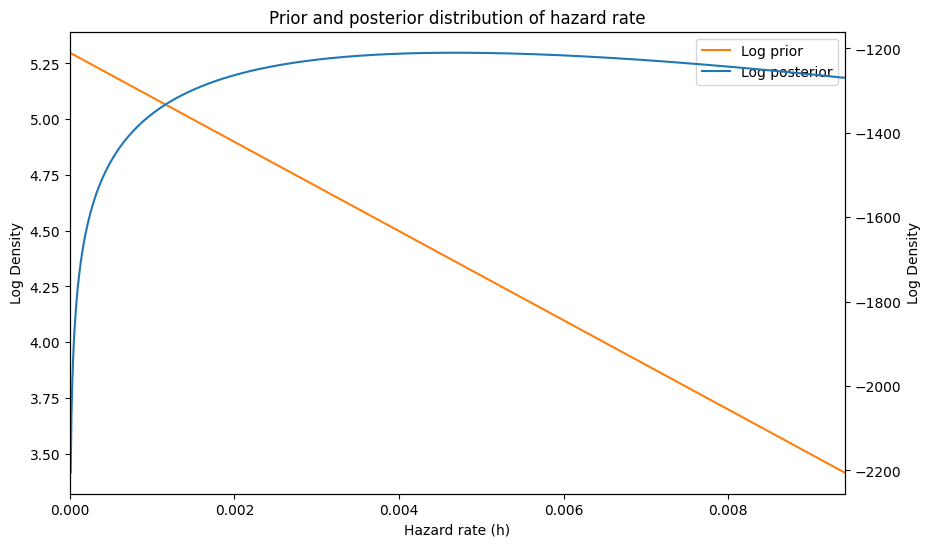

In [ ]:
h_values = np.linspace(0, 191 * 2 / 40550, 1000)
log_posterior_values = log_constant_rate_posterior(h_values, alpha, beta)
log_prior_values = np.log(expon(h_values, a=alpha, scale=1/beta))

fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()
p1 = ax.plot(h_values, log_prior_values, color="tab:orange", label="Log prior")
p2 = ax2.plot(h_values, log_posterior_values, color="tab:blue", label="Log posterior")

ax.set_xlabel("Hazard rate (h)")
ax.set_ylabel("Log Density")
ax.set_title("Prior and posterior distribution of hazard rate")
ax.set_xlim(0, 191 * 2 / 40550)
ax2.set_ylabel("Log Density")

ps = p1 + p2
labels = [p.get_label() for p in ps]
ax.legend(ps, labels, loc=0)

plt.show()

Computing the evidence from the unnormalised posterior requires scaling the integrand by a constant to avoid underflow errors. The evidence is given by

\begin{equation}
    Z=\int_0^\infty 200h_0^N\exp(-h_0(200+L))dh_0.
\end{equation}

We can compute the maximum of the log-integrand, which turns out to be at $h_0=\frac{N}{200+L}$. Subtracting the log-integrand evaluated at this point we get

\begin{equation}
    \log\tilde{P}=\log P+\text{const}=N(\log\frac{h_0(200+L)}{N}+1)-h_0(200+L),
\end{equation}

where $\text{const}=\log(200(\frac{N}{200+L})^N)\exp(-N)$. With this, the evidence is given by

\begin{equation}
    Z=\exp(-\text{const})\int\exp\tilde{P}dh_0.
\end{equation}

In [8]:
from scipy.integrate import quad

def exp_scaled_log_integrand(h):
    return np.exp(total_events * (np.log(h * (200 + total_period)/total_events) + 1) - h * (200 + total_period))

scaled_evidence, _ = quad(exp_scaled_log_integrand, 0, 1)
print(f"Scaled evidence: {scaled_evidence:.10e}")

Scaled evidence: 8.5048858166e-04


The prefactor in the evidence $\exp(\text{const})$ is tiny. With the given parameters, it evaluates to

\begin{equation}
    200\biggl(\frac{191}{40750}\biggr)^{191}\exp(-191) = 3.12\times10^{-526}.
\end{equation}

As a result, the total evidence is

\begin{equation}
    Z=2.65\times10^{-529},
\end{equation}

\begin{equation}
    \log Z=-1217.09.
\end{equation}

## Question 4: The 1 change point model

### (a)

I have used the package `emcee` which implements an affine-invariant Markov Chain Monte Carlo ensemble sampler. Hamiltonian Monte Carlo and the No-U-Turn Sampler require continuous and differentiable likelihoods for computing gradients. Since this likelihood is discontinuous and not differentiable at one point, and later will be so at $k$ points, these algorithms will be inappropriate to use.

I initialise 50 walkers for each parameter which is significantly higher than the minimum recommendation for this problem ($2\times n_\text{dim}$) while still computing in under 20 seconds. I also use 20,000 steps for the algorithm to ensure that there are at least 50 independent samples per walker once thinned. This will yield tight constraints on parameter values since the Monte Carlo error scales as $1/\sqrt{N}$. I also conservatively discard the first 20% of each chain to remove burn-in as the chains find the bulk of the posterior.

To assess convergence, I compute the integrated autocorrelation timescale which is the standard measure used in such problems. It gives an estimate of the number of samples in a chain between independent samples. I then use this value to thin the chains for later inference. For this problem, the Gelman-Rubin ratio is an inappropriate measure of convergence since it assumes that each chain is independent of one another, which is not true for ensemble MCMC algorithms. This would lead to false positives for convergence, which is undesirable as it would suggest that sampling should be terminated prematurely. I also check that the mean acceptance fraction is in a sensible range (10-50%) and visually inspect the trace plots once burn-in is removed. I measure an acceptance fraction at the top of this range, which is appropriate for a low-dimensional problem and indicates that the chains are making large enough steps to explore the high posterior density regions efficiently, while the trace plots exhibit the expected behaviour.

In [9]:
import emcee

alpha_param = 1
beta_param = 200

# The change point s_1 is a parameter of the model. The others are h_0 and h_1. We need to count the number of accidents occuring before and after the change
# point s_1, denoted n_0 and n_1 respectively. We also need to calculate the total time spent before and after the change point, denoted T_0 and T_1 
# respectively. The likelihood of the data given the parameters can be expressed as:
# L(h_0, h_1, s_1) = (h_0^n_0 * exp(-h_0 * T_0)) * (h_1^n_1 * exp(-h_1 * T_1))

def log_likelihood(h_0, h_1, s_1):
    n_0 = np.sum(flattened_data_cumulative < s_1)
    n_1 = np.sum(flattened_data_cumulative > s_1)
    T_0 = s_1
    T_1 = total_period - s_1
    log_likelihood_value = n_0 * np.log(h_0) - h_0 * T_0 + n_1 * np.log(h_1) - h_1 * T_1
    if h_0 <= 0 or h_1 <= 0 or s_1 <= 0 or s_1 >= total_period:
        return -np.inf  # Log of zero probability
    else:
        return log_likelihood_value

def log_prior(h_0, h_1, s_1):
    if h_0 <= 0 or h_1 <= 0 or s_1 <= 0 or s_1 >= total_period:
        return -np.inf  # Log of zero probability
    else:
        return alpha * np.log(beta_param) - beta_param * h_0 + alpha * np.log(beta_param) - beta_param * h_1 + np.log(s_1) + np.log(total_period - s_1) - 3 * np.log(total_period)
    
def log_posterior(params):
    h_0, h_1, s_1 = params
    return log_prior(h_0, h_1, s_1) + log_likelihood(h_0, h_1, s_1)

ndim = 3
nwalkers = 50
nsteps = 20000
nburnin = 4000

# Initialize walkers around estimated sensible values
# s1 ~ L/2, h ~ N/L
start_pos = np.zeros((nwalkers, ndim))
start_pos[:, 0] = np.random.uniform(10000, 30000, nwalkers)  # s1
start_pos[:, 1] = np.random.normal(0.005, 0.001, nwalkers)   # h0
start_pos[:, 2] = np.random.normal(0.002, 0.001, nwalkers)   # h1

# Ensure starting positions are strictly positive for h0, h1
start_pos[:, 1:] = np.abs(start_pos[:, 1:])

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(start_pos, nsteps, progress=True)
autocorrtime = sampler.get_autocorr_time()
print(f"Autocorrelation time for sampler: {autocorrtime}")
thinning_factor = int(autocorrtime.max())
samples = sampler.get_chain(discard=nburnin, thin=thinning_factor, flat=True)

# Compute mean acceptance fraction
acceptance_fraction = sampler.acceptance_fraction
print(f"Mean acceptance fraction: {np.mean(acceptance_fraction):.4f}")

  0%|          | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_39113/2875680762.py:16: RuntimeWarning: invalid value encountered in log
  log_likelihood_value = n_0 * np.log(h_0) - h_0 * T_0 + n_1 * np.log(h_1) - h_1 * T_1
100%|██████████| 20000/20000 [00:13<00:00, 1451.11it/s]


Autocorrelation time for sampler: [ 22.27314108 124.82338699 233.60591474]
Mean acceptance fraction: 0.4967


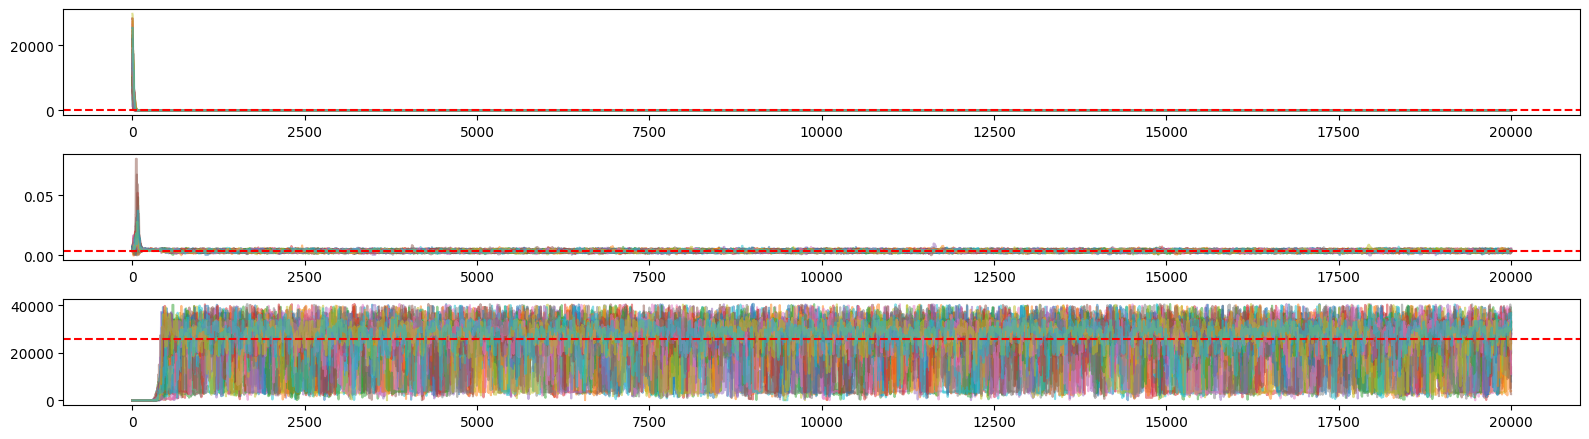

In [10]:
# Plot unthinned chains with burn in
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.show()

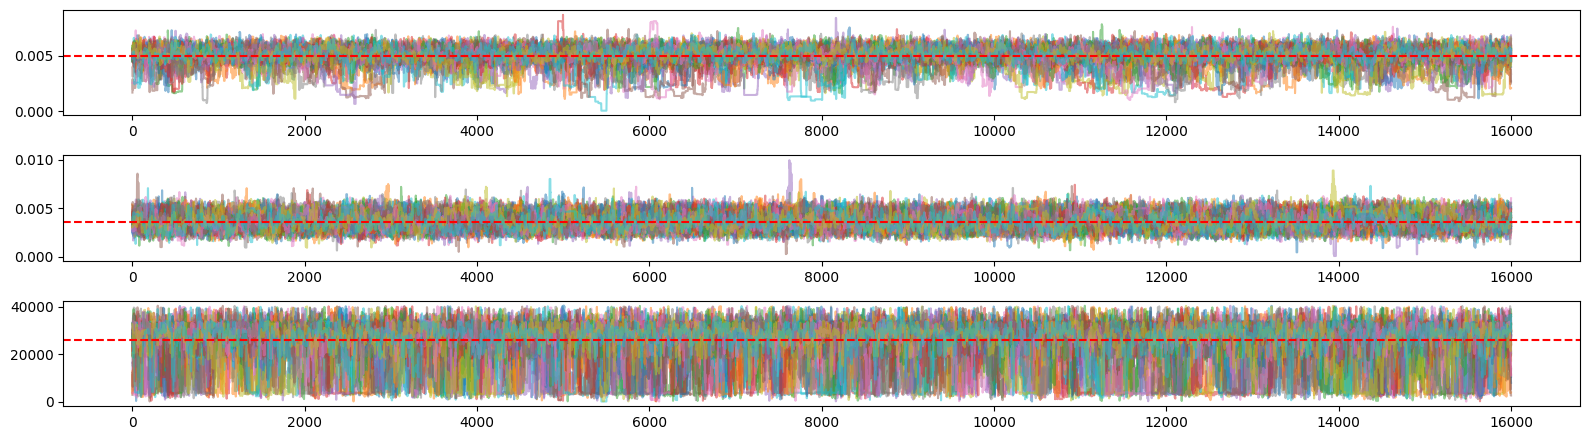

In [11]:
# Plot with burn in removed
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain(discard=nburnin)[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.show()

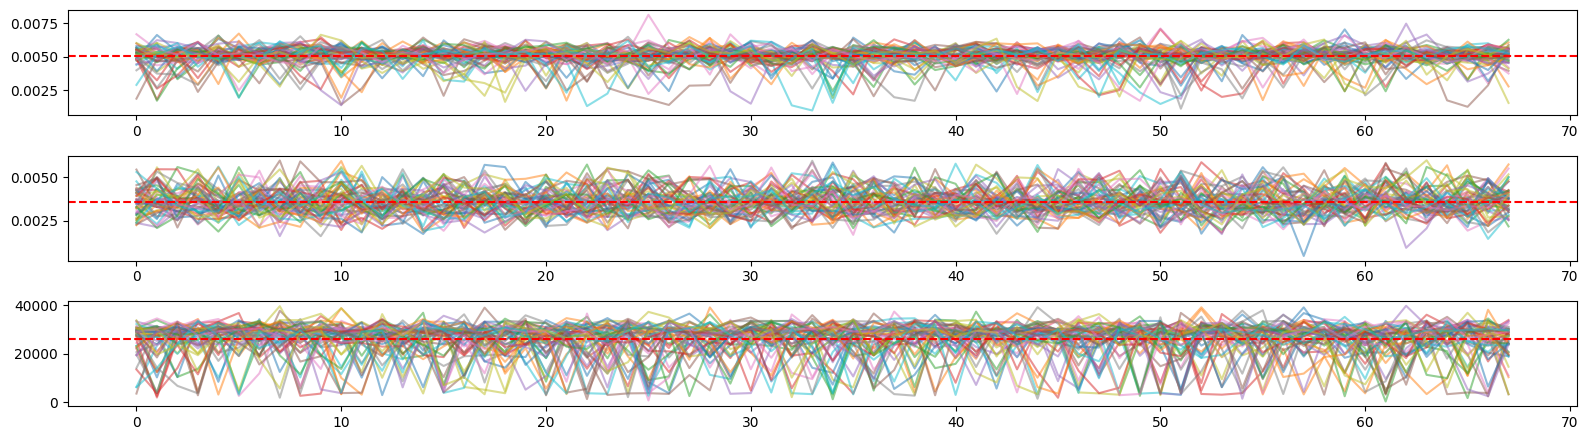

In [12]:
# Plot with burn in removed and chains thinned
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain(discard=nburnin, thin=thinning_factor)[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.show()

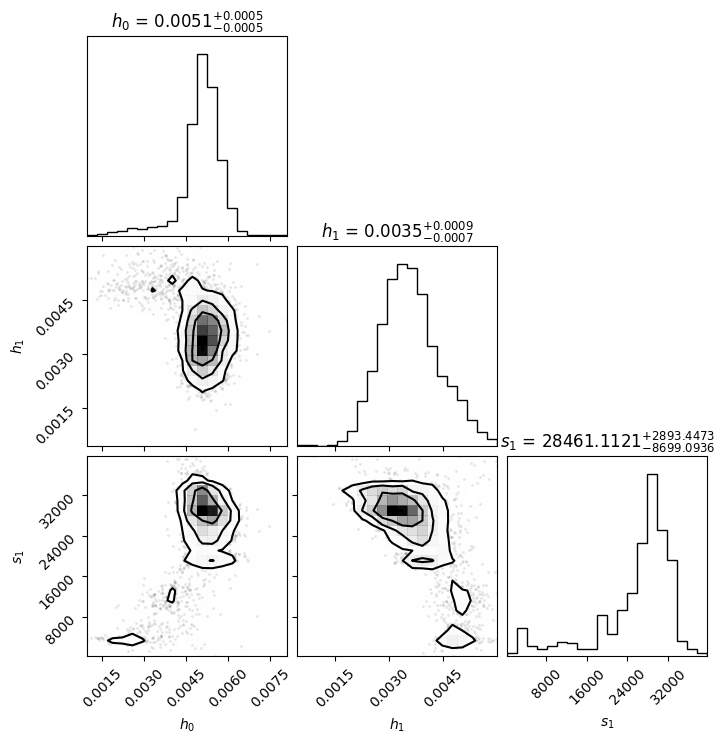

In [13]:
import corner
labels = ["$h_0$", "$h_1$", "$s_1$"]
fig = corner.corner(samples.reshape(-1, ndim), labels=labels, show_titles=True, title_fmt=".4f", title_kwargs={"fontsize": 12})
plt.show()

### (b)

Consider two models $M_0$ and $M_1$ with parameters $\phi$ and $(\epsilon,\phi)$ respectively. We say that $M_0$ is nested within $M_1$ if for some fixed value of $\epsilon$, say $\epsilon_0$, the two models have the same likelihood function:

\begin{equation*}
    \mathcal{L}(d|\phi,M_0)=\mathcal{L}(d|\epsilon=\epsilon_0,\phi,M_1).
\end{equation*}

To use the Savage-Dickey ratio, we require that the two models also have consistent priors i.e.

\begin{equation*}
    \pi(\phi|M_0)=\pi(\phi|\epsilon=\epsilon_0,M_1).
\end{equation*}

The prior for the simpler model can be expressed as

\begin{equation*}
    Z_{M_0}=P(d|M_0)=\int d\phi\mathcal{L}(d|\phi,M_0)\pi(\phi|M_0)\\
    =\int d\phi\mathcal{L}(d|\epsilon=\epsilon_0,\phi,M_1)\pi(\phi|\epsilon=\epsilon_0,M_1)=P(d|\epsilon=\epsilon_0, M_1)
\end{equation*}

\begin{equation*}
    Z_{M_0}=\frac{P(\epsilon=\epsilon_0|d,M_1)}{P(\epsilon=\epsilon_0|M_1)}P(d|M_1).
\end{equation*}

We can then write the Bayes factor, defined as the ratio of the evidences under each model, as the ratio of a 1-dimensional posterior PDF to the 1-dimension prior PDF both evaluated at $\epsilon=\epsilon_0$:

\begin{equation*}
    \mathcal{B}_{01}=\frac{P(\epsilon=\epsilon_0|d,M_1)}{P(\epsilon=\epsilon_0|M_1)}.
\end{equation*}

The prior in the denominator is usually an analytic function, so is easy to evaluate, while the posterior is more difficult. Typically, you would use an MCMC algorithm, discarding values of any irrelevant parameters to estimate the posterior on $\epsilon$ which can then be evaluated through a kernel density estimate (KDE), for example. When computing the KDE, values of $\epsilon=\epsilon_0$ on the boundary of the prior can bias the density estimate. The model $M_0$ is recovered by setting $k=0$, which is on the boundary of the prior and may bias the KDE.

### (c)

The Laplace approximation in the multivariate case approximates the logarithm of the posterior PDF $\log P(\vec{x})$ using a Taylor expansion about its maximal point $\hat{\vec{x}}$. Here, all first derivates with respect to the model parameters $\vec{x}$ vanish, leaving

\begin{equation}
    \log P(\vec{x}) = \log P(\hat{\vec{x}}) - \frac{C_{ij}}{2}(\vec{x}_i-\hat{\vec{x}}_i)(\vec{x}_j-\hat{\vec{x}}_j)+...,
\end{equation}

where $C_{ij}=-\frac{\partial^2}{\partial x_i\partial x_j}\biggl|_{\vec{x}=\hat{\vec{x}}}\log P(\vec{x})$ is the Hessian of the log-posterior. The approximate posterior PDF is then a multivariate Gaussian distribution

\begin{equation}
    P(\vec{x})\approx P(\hat{\vec{x}})\exp(-\frac{C_{ij}}{2}(\vec{x}-\hat{\vec{x}})).
\end{equation}

The evidence is then easily computed using properties of the multivariate Gaussian distribution given by

\begin{equation}
    Z\approx P(\hat{\vec{x}})\sqrt{\frac{(2\pi)^D}{\text{det}(\mathbf{C})}}.
\end{equation}

The Laplace approximation relies on the posterior PDF being continuous and differentiable everywhere to compute the Hessian matrix. The posterior PDF changes discontinuously at the change points, so the assumption breaks down and the Laplace approximation cannot be used for this problem.

### (d)

Here I use `dynesty` to perform nested sampling, which takes as input the log-likelihood and a function that defines a transformation from the 

In [ ]:
from dynesty import NestedSampler
import scipy
from scipy.stats import beta, expon

def log_likelihood(params):
    s_1 = params[0]
    h_0 = params[1]
    h_1 = params[2]
    n_0 = np.sum(flattened_data_cumulative < s_1)
    n_1 = np.sum(flattened_data_cumulative > s_1)
    T_0 = s_1
    T_1 = total_period - s_1
    log_likelihood_value = n_0 * np.log(h_0) - h_0 * T_0 + n_1 * np.log(h_1) - h_1 * T_1
    if h_0 <= 0 or h_1 <= 0 or s_1 <= 0 or s_1 >= total_period:
        return -np.inf  # Log of zero probability
    else:
        return log_likelihood_value

def prior_transform(u):
    """
    Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest.
     - h_0 and h_1 are drawn from a gamma distribution with rate beta_param = 200 days and alpha_param = 1
     - s_1 is drawn from a Dirichlet distribution with k=2 and alpha parameters equal to 2. 
    """
    x = np.array(u)
    x[0] = beta.ppf(u[0],2,2)
    x[1] = expon.ppf(u[1], scale=1/beta_param)
    x[2] = expon.ppf(u[2], scale=1/beta_param)
    return x

sampler = NestedSampler(log_likelihood, prior_transform, ndim, nlive=500)

In [24]:
sampler.run_nested()
results = sampler.results
print(results)
results.summary()

1840it [00:00, 32328.62it/s, +500 | bound: 1 | nc: 1 | ncall: 18855 | eff(%): 12.749 | loglstar:   -inf < -1209.017 <    inf | logz: -1211.795 +/-  0.067 | dlogz:  0.001 >  0.509]

          nlive: 500
          niter: 1840
          ncall: array([1, 1, 1, ..., 1, 1, 1], shape=(2340,))
            eff: 12.74856987196949
        samples: array([[6.36587518e-01, 3.73445572e-03, 4.49851737e-02],
       [4.13800671e-01, 7.05784500e-03, 5.83408270e-06],
       [6.21581910e-01, 6.64994438e-04, 2.27623119e-05],
       ...,
       [7.95868863e-01, 1.21135201e-03, 4.68071631e-03],
       [9.19123384e-01, 6.82825389e-04, 4.69568915e-03],
       [8.70012569e-01, 7.14888842e-04, 4.68459068e-03]], shape=(2340, 3))
           blob: array([None, None, None, ..., None, None, None],
      shape=(2340,), dtype=object)
 proposal_stats: array([{'n_proposals': 1}, {'n_proposals': 1}, {'n_proposals': 1}, ...,
       None, None, None], shape=(2340,), dtype=object)
     samples_id: array([226, 186, 263, ..., 375, 241, 193], shape=(2340,))
     samples_it: array([   0,    0,    0, ..., 1379,  800, 1394], shape=(2340,))
      samples_u: array([[0.69978488, 0.52616264, 0.99987622],
       

## References

1. [emcee ReadTheDocs](https://emcee.readthedocs.io/en/stable/)
2. [Ensemble samplers with affine invariance (Goodman and Weare)](https://msp.org/camcos/2010/5-1/p04.xhtml)
3. [zeus ReadTheDocs](https://zeus-mcmc.readthedocs.io/en/latest/index.html)
4. [Ensemble slice samplers](https://arxiv.org/pdf/2002.06212)
5. [zeus paper](https://arxiv.org/pdf/2105.03468)